# **SEMIFINAL BIG DATA CHALLANGE 2024**

## TIM      = SD2024040000266
- Ketua     = Hajran Azbytama Winarya
- Anggota 1 = Billiarto Sastro Cemerson
- Anggota 2 = Muhammad Goldy Wahyu Haryadi

## **SOCIAL NETWORK ANALYSIS**

In [ ]:
# IMPORT LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
import seaborn as sns
import re
import zipfile
import patoolib
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GAE, InnerProductDecoder
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx
from sklearn.metrics import silhouette_score
from torch_geometric.utils import to_dense_adj
from torch_geometric.nn import SAGEConv
from sklearn.metrics import silhouette_score
from collections import defaultdict, Counter
import community as community_louvain  # Louvain community detection
from networkx.algorithms.community import louvain_communities

# **EDA**

In [ ]:
# Now try reading the CSV as before
data = pd.read_csv(r"D:\Lomba-Lomba\BDC Satria Data 2024\SEMIFINAL\data\encrypted_merge.csv")
data.head()

,created_at,username,tcode,num_retweets,type,frn_cnt,flw_cnt,sts_cnt,loc,lst_cnt,content,lang
0,2024-01-04T09:57:09Z,@QOS7XYPBfXZWFeLSmdLEt8njUMwwr2Fpel3Cqvh2gW4=,rt,1248,twit,266.0,107.0,9687.0,NaN,0.0,RT K-Popers Berencana Kirim Food Truck untuk A...,id
1,2024-01-04T09:57:09Z,@lSDenDKpcZVnv9txjBcg5qaqxYgVAq/3gTvA8yxPuL4=,rt,195,twit,564.0,303.0,12461.0,indonesia kaya,2.0,RT Bapak Pendeta Yusak ini Dari Magetan ke Pon...,id
2,2024-01-04T09:57:10Z,@Ykjdr3xs5+WfH9zBQMoAx5fdTeAwmRRm28PFVw5JeJE=,rt,116,twit,376.0,156.0,7488.0,Indonesia,1.0,"RT Viral , Gimana Mak Mak di jakarta tidak ter...",id
3,2024-01-04T09:57:10Z,@KQ/OmqgBG/U/OVkvpqAQYYiAThFGxQBtg3J5Vjp4Glk=,rt,2264,twit,163.0,203.0,2065.0,NaN,0.0,"RT Mendengar Pak Anies disini, rasanya saya su...",id
4,2024-01-04T09:57:11Z,@yqECLRUCZgqx8VzEUl430Wj6mfh2SgDYzKwala0bT5o=,rt,1157,twit,1.0,1.0,798.0,NaN,0.0,RT Media Asing Soroti Cara Anies Gaet Pemilih ...,id


In [ ]:
data['content'].iloc[100]

'RT *Ternyata Anies lebih gila.. share ke semua group agar kita semua bangga menjadi Anak bangsa Indonesia.... *Penuh Prestasi, bukan karya abal"* @3Tjp36eJnhtxKV6+eda7ePjoV/mqZDqvEkIKSi894Q8= @N9oi5FP8jAxnYyFx6RDIX+rU56ecKSfQ6/LcjaIRGlE= @Y8Fy/cAfNGsrrc5k0CzsGu2wN1wtCZn+MJTmYgiF0HQ= @oB+6/vomIEsmvU/iojlgddyffv3jPktoHs7d20CoOVk= @Rd291CBLJWgmE2B98hkKtTJPv36HzKXouARM9zas6O8= @ajF0lBhjPmRIT3q/c72UPlseY6Ixb1za8ANOgyFmVvQ= @fKLxvpqIbJr8OG8wjjoFYpmMCPHWmEROq/+6l2KSIss= https://t.co/8vJy8SVKg4 [RE Andria75777]'

In [ ]:
# Memeriksa baris dengan @t atau @a
rows_with_invalid_usernames = data[data['content'].apply(lambda x: '@bawaslu_RI ' in x)]

# Menampilkan baris yang mengandung @t atau @a
rows_with_invalid_usernames.head()

,created_at,username,tcode,num_retweets,type,frn_cnt,flw_cnt,sts_cnt,loc,lst_cnt,content,lang
534021,2024-01-02T00:35:38Z,@Wtkinf6QcrdkYpqm561+ofv1/U35yy3YtyWGa5qEKDg=,reply,0,twit,371.0,126.0,10152.0,NaN,0.0,@M1i2ZAmyp7q4MysyxJOmHleW/rJ2W7E4qBOfO79Sozs= ...,id
1994303,2024-01-15T01:28:22Z,@jKFCnZn515z3HR9byJWR9UGIyKxSPeuS/HqNXE637ac=,reply,0,twit,11.0,8.0,1281.0,NaN,0.0,@YcZGyEZ3QT5ArfNpBChy4xnvmaJ6Yb2FfMHy0ERhfl8= ...,id
3583046,2024-01-18T02:30:00Z,@f9dQoqpSDdGV4CPer6DqfnNzVVEOy88fhlN9SBFaeFY=,reply,0,twit,573.0,95.0,9070.0,"DKI Jakarta, Indonesia",0.0,@XarZiwh5CQaSO82X1AZgs1z25nxrPjOIrTL0KSYkAJs= ...,id


# **PREPOCESSING**

In [ ]:
def extract_usernames(content):
    # Regular expression untuk menangkap berbagai bentuk username
    usernames = re.findall(r'@[A-Za-z0-9_]+[A-Za-z0-9_+/=]*', content)
    return usernames

In [ ]:
# Membuat kolom baru dengan username yang disebutkan
data['mentioned_usernames'] = data['content'].apply(extract_usernames)

In [ ]:
# Menyaring baris dengan mentioned_usernames yang tidak kosong
df = data[data['mentioned_usernames'].map(len) > 0]

In [ ]:
# Drop the unnecessary column
df.drop(columns=['created_at', 'loc', 'type', 'lang'], inplace=True)

# Filter data with lang='id'
#df = df[df['lang'] == 'id']

# Drop rows with NA values
df.dropna(inplace=True)

C:\Users\HAJRAN\AppData\Local\Temp\ipykernel_22292\241369043.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['created_at', 'loc', 'type', 'lang'], inplace=True)
C:\Users\HAJRAN\AppData\Local\Temp\ipykernel_22292\241369043.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


In [ ]:
# Fungsi untuk mengurai kolom mentioned_usernames dan membuat kolom baru content_username
def explode_usernames(df):
    # Mengurai kolom mentioned_usernames sehingga setiap baris hanya memiliki satu username dalam kolom content_username
    df_exploded = df.explode('mentioned_usernames')

    # Menamakan ulang kolom mentioned_usernames menjadi content_username
    df_exploded = df_exploded.rename(columns={'mentioned_usernames': 'content_username'})

    return df_exploded

In [ ]:
# Menggunakan fungsi untuk mengurai kolom mentioned_usernames
df_exploded = explode_usernames(df)

In [ ]:
df_exploded.to_csv(r'D:\Lomba-Lomba\BDC Satria Data 2024\SEMIFINAL\data\df_exploded.csv', index=False)

In [ ]:
df_exploded

,username,tcode,num_retweets,frn_cnt,flw_cnt,sts_cnt,lst_cnt,content,content_username
34,@7WZM6I5Q/iYrH1SMgclp34S65jhXMMyhXdvYbR3TO9s=,reply,0,347.0,207.0,6378.0,1.0,@TaMJoOLodMKkoLGb6D7kQt0Xu9UOcQLMRZLaYsmTms8= ...,@TaMJoOLodMKkoLGb6D7kQt0Xu9UOcQLMRZLaYsmTms8=
38,@5bcvctYrjL1R7+juB8TjhVbDqjgCOCKLMJVerK5CqF4=,reply,0,153.0,124.0,319.0,0.0,@9GXTLEV8XmbSNpLSZCd8HnOrQ/uhyesXNsSF+M0gi4Q= ...,@9GXTLEV8XmbSNpLSZCd8HnOrQ/uhyesXNsSF+M0gi4Q=
38,@5bcvctYrjL1R7+juB8TjhVbDqjgCOCKLMJVerK5CqF4=,reply,0,153.0,124.0,319.0,0.0,@9GXTLEV8XmbSNpLSZCd8HnOrQ/uhyesXNsSF+M0gi4Q= ...,@DjhbOyAS8Jpmn89wvMwSKAFwUhRyKGJjW/6oiUCfEzY=
39,@frAtGFoe5QExA7+rfzOX6vqrbItjXQdZkORwO0DWHW0=,reply,0,278.0,94.0,8740.0,0.0,@5Tz753nhSrc3MyKUjKPGAKQ59HMT5TnaXVJrYBVFXro= ...,@5Tz753nhSrc3MyKUjKPGAKQ59HMT5TnaXVJrYBVFXro=
49,@TvRgC0b8jDOs/pDZYvZAVll4/4/IbdDYm11BvnFouEE=,reply,0,10.0,5.0,1970.0,0.0,@HUo2P8p6enbSrHhNtJhdkhUGz+KnIaG9j7IK6F0uJSg= ...,@HUo2P8p6enbSrHhNtJhdkhUGz+KnIaG9j7IK6F0uJSg=
...,...,...,...,...,...,...,...,...,...
9817339,@eJ27V3obbOv7bS0sI/N6ucsXMAyPNu4SfkhfaAr+U/U=,rt,927,66.0,10643.0,39103.0,26.0,RT SURAT TERBUKA CAPRES RI HARUS TOTALITAS DAL...,@k5krH6DyHMIz8/ySQJWMts+GCBo5JDvehRB4b0rZHH4=
9817339,@eJ27V3obbOv7bS0sI/N6ucsXMAyPNu4SfkhfaAr+U/U=,rt,927,66.0,10643.0,39103.0,26.0,RT SURAT TERBUKA CAPRES RI HARUS TOTALITAS DAL...,@e/0tSq/3D6e7jxMaYSMaZetvS7fjQGllC+ey6LYOZFM=
9817339,@eJ27V3obbOv7bS0sI/N6ucsXMAyPNu4SfkhfaAr+U/U=,rt,927,66.0,10643.0,39103.0,26.0,RT SURAT TERBUKA CAPRES RI HARUS TOTALITAS DAL...,@4S1G8lElhl4pC3dcKmh4BWofvqWvOAI94JbkLKyGnFw=
9817352,@KhXOHuWg3rF+tH/IvnVdIKE6gkQoU5+CqePqmIFFrQg=,rt,151,143.0,56.0,2932.0,0.0,RT Tetap semangat pak @kYo4g8BWrOVt8nzENmM18Ff...,@kYo4g8BWrOVt8nzENmM18FfwvHQbjIHpX/KRpXDcsFk=


### **Data Exploded**

In [ ]:
df_exploded = pd.read_csv(r'D:\Lomba-Lomba\BDC Satria Data 2024\SEMIFINAL\data\df_exploded.csv')

In [ ]:
df_exploded['tcode'].value_counts()

In [ ]:
df_with_anomali = df_exploded[df_exploded['content_username'].str.match(r'^@t$', na=False)]

In [ ]:
df_with_anomali2 = df_exploded[df_exploded['content_username'].str.match(r'^@a$', na=False)]

In [ ]:
# Menghapus baris yang memiliki content_username tepat sama dengan '^@a$' atau '6@t$'
data = df_exploded.drop(df_exploded[(df_exploded['content_username'] == '@a') | (df_exploded['content_username'] == '@t') | (df_exploded['content_username'] == '@gmail')].index)

In [ ]:
data['tcode'].value_counts()

In [ ]:
data.to_csv('/content/drive/My Drive/BDC-SatriaData-2024/SEMIFINAL/data_clean.csv', index=False)

### PROSES MODELLING

In [ ]:
#IMPORT DATA CLEAN
data = pd.read_csv(r"D:\Lomba-Lomba\BDC Satria Data 2024\SEMIFINAL\sna\data_clean.csv")
data.head()

,username,tcode,num_retweets,frn_cnt,flw_cnt,sts_cnt,lst_cnt,content,content_username
0,@7WZM6I5Q/iYrH1SMgclp34S65jhXMMyhXdvYbR3TO9s=,reply,0,347.0,207.0,6378.0,1.0,@TaMJoOLodMKkoLGb6D7kQt0Xu9UOcQLMRZLaYsmTms8= ...,@TaMJoOLodMKkoLGb6D7kQt0Xu9UOcQLMRZLaYsmTms8=
1,@5bcvctYrjL1R7+juB8TjhVbDqjgCOCKLMJVerK5CqF4=,reply,0,153.0,124.0,319.0,0.0,@9GXTLEV8XmbSNpLSZCd8HnOrQ/uhyesXNsSF+M0gi4Q= ...,@9GXTLEV8XmbSNpLSZCd8HnOrQ/uhyesXNsSF+M0gi4Q=
2,@5bcvctYrjL1R7+juB8TjhVbDqjgCOCKLMJVerK5CqF4=,reply,0,153.0,124.0,319.0,0.0,@9GXTLEV8XmbSNpLSZCd8HnOrQ/uhyesXNsSF+M0gi4Q= ...,@DjhbOyAS8Jpmn89wvMwSKAFwUhRyKGJjW/6oiUCfEzY=
3,@frAtGFoe5QExA7+rfzOX6vqrbItjXQdZkORwO0DWHW0=,reply,0,278.0,94.0,8740.0,0.0,@5Tz753nhSrc3MyKUjKPGAKQ59HMT5TnaXVJrYBVFXro= ...,@5Tz753nhSrc3MyKUjKPGAKQ59HMT5TnaXVJrYBVFXro=
4,@TvRgC0b8jDOs/pDZYvZAVll4/4/IbdDYm11BvnFouEE=,reply,0,10.0,5.0,1970.0,0.0,@HUo2P8p6enbSrHhNtJhdkhUGz+KnIaG9j7IK6F0uJSg= ...,@HUo2P8p6enbSrHhNtJhdkhUGz+KnIaG9j7IK6F0uJSg=


### Memilih Username yang disebutkan muncul lebih dai 1, 5, 10, 20, 100, 500 kali

In [ ]:
username_counts = data['content_username'].value_counts()

# Pilih hanya username yang muncul lebih dari 1 kali
valid_usernames = username_counts[username_counts > 1].index

# Filter dataframe dengan username yang valid
data_reduced = data[data['content_username'].isin(valid_usernames)]

In [ ]:
username_counts = data['content_username'].value_counts()

# Pilih hanya username yang muncul lebih dari 5 kali
valid_usernames = username_counts[username_counts > 5].index

# Filter dataframe dengan username yang valid
data_reduced = data[data['content_username'].isin(valid_usernames)]

In [ ]:
username_counts = data['content_username'].value_counts()

# Pilih hanya username yang muncul lebih dari 10 kali
valid_usernames = username_counts[username_counts > 10].index

# Filter dataframe dengan username yang valid
data_reduced = data[data['content_username'].isin(valid_usernames)]

In [ ]:
username_counts = data['content_username'].value_counts()

# Pilih hanya username yang muncul lebih dari 20 kali
valid_usernames = username_counts[username_counts > 20].index

# Filter dataframe dengan username yang valid
data_reduced = data[data['content_username'].isin(valid_usernames)]

In [ ]:
username_counts = data['content_username'].value_counts()

# Pilih hanya username yang muncul lebih dari 100 kali
valid_usernames = username_counts[username_counts > 100].index

# Filter dataframe dengan username yang valid
data_reduced = data[data['content_username'].isin(valid_usernames)]

In [ ]:
username_counts = data['content_username'].value_counts()

# Pilih hanya username yang muncul lebih dari 500 kali
valid_usernames = username_counts[username_counts > 500].index

# Filter dataframe dengan username yang valid
data_reduced = data[data['content_username'].isin(valid_usernames)]

In [ ]:
data_reduced.info()

In [ ]:
data_reduced['tcode'].value_counts()

rt         13741
mention     1262
reply        819
Name: tcode, dtype: int64

### Memilih username > 1

### Pemilihan Variabel Interaksi (Kolom tcode)

- reply
- mention
- rt
- all_interaction (reply, mention, rt)

In [ ]:
data_reduced.value_counts()

In [ ]:
# Filter interaksi mention reply
mention_df = data_reduced[data_reduced['tcode'] == 'reply']

In [ ]:
# Filter interaksi mention mention
mention_df = data_reduced[data_reduced['tcode'] == 'mention']

In [ ]:
# Filter interaksi mention rt
mention_df = data_reduced[data_reduced['tcode'] == 'rt']

In [ ]:
# Filter interaksi mention all_interaction
mention_df = data_reduced[data_reduced['tcode'].isin(['reply', 'mention','rt'])]

## USING Model GCL (Graph Contrastive Learning) + LOUVEN

In [ ]:
# Create graph
G = nx.Graph()
for _, row in mention_df.iterrows():
    G.add_edge(row['username'], row['content_username'])

# Convert graph to PyTorch Geometric format
node_mapping = {node: i for i, node in enumerate(G.nodes())}
edge_index = torch.tensor([[node_mapping[u], node_mapping[v]] for u, v in G.edges()]).t().contiguous()
x = torch.eye(len(G.nodes()))  # Simple one-hot encoded node features

data = Data(x=x, edge_index=edge_index)

class GCNEncoder(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super(GCNEncoder, self).__init__()
        self.conv1 = GCNConv(in_channels, 2 * out_channels)
        self.conv2 = GCNConv(2 * out_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        return self.conv2(x, edge_index)

class GraphContrastiveLearning(torch.nn.Module):
    def __init__(self, encoder, hidden_dim):
        super(GraphContrastiveLearning, self).__init__()
        self.encoder = encoder
        self.decoder = InnerProductDecoder()

    def forward(self, x, edge_index):
        z = self.encoder(x, edge_index)
        return z

    def recon_loss(self, z, pos_edge_index, neg_edge_index):
        pos_loss = -torch.log(
            self.decoder(z, pos_edge_index, sigmoid=True) + 1e-15).mean()
        neg_loss = -torch.log(1 - self.decoder(z, neg_edge_index, sigmoid=True) + 1e-15).mean()
        return pos_loss + neg_loss

# Initialize model and optimizer
hidden_dim = 64
encoder = GCNEncoder(data.num_features, hidden_dim)
model = GraphContrastiveLearning(encoder, hidden_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

def train():
    model.train()
    optimizer.zero_grad()
    z = model(data.x, data.edge_index)
    neg_edge_index = torch.randint(0, data.num_nodes, data.edge_index.size(), dtype=torch.long)
    loss = model.recon_loss(z, data.edge_index, neg_edge_index)
    loss.backward()
    optimizer.step()
    return loss

# Training loop
for epoch in range(200):
    loss = train()
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')



Epoch 0, Loss: 1.3705
Epoch 10, Loss: 0.8796
Epoch 20, Loss: 0.8229
Epoch 30, Loss: 0.8236
Epoch 40, Loss: 0.7836
Epoch 50, Loss: 0.7817
Epoch 60, Loss: 0.7679
Epoch 70, Loss: 0.7853
Epoch 80, Loss: 0.7697
Epoch 90, Loss: 0.7491
Epoch 100, Loss: 0.7605
Epoch 110, Loss: 0.7748
Epoch 120, Loss: 0.7512
Epoch 130, Loss: 0.7601
Epoch 140, Loss: 0.7679
Epoch 150, Loss: 0.7744
Epoch 160, Loss: 0.7601
Epoch 170, Loss: 0.7540
Epoch 180, Loss: 0.7486
Epoch 190, Loss: 0.7420


## louvain for comunity detection

In [ ]:
# Generate node embeddings
model.eval()
with torch.no_grad():
    node_embeddings = model(data.x, data.edge_index).numpy()

# Convert embeddings back to dictionary with username
username_embeddings = {node: node_embeddings[i] for node, i in node_mapping.items()}

# Community detection using Louvain
partition = community_louvain.best_partition(G)
community_labels = {node: partition[node] for node in G.nodes()}

# Remove small communities
def remove_small_communities(community_labels, min_size=50):
    community_sizes = defaultdict(int)
    for node, comm in community_labels.items():
        community_sizes[comm] += 1

    large_communities = {comm for comm, size in community_sizes.items() if size >= min_size}

    new_community_labels = {}
    for node, comm in community_labels.items():
        if comm in large_communities:
            new_community_labels[node] = comm
        else:
            new_community_labels[node] = 'Other'

    return new_community_labels

new_community_labels = remove_small_communities(community_labels, min_size=50)



### VISUALIZATION COMMUNITY GCL + LOUVEN

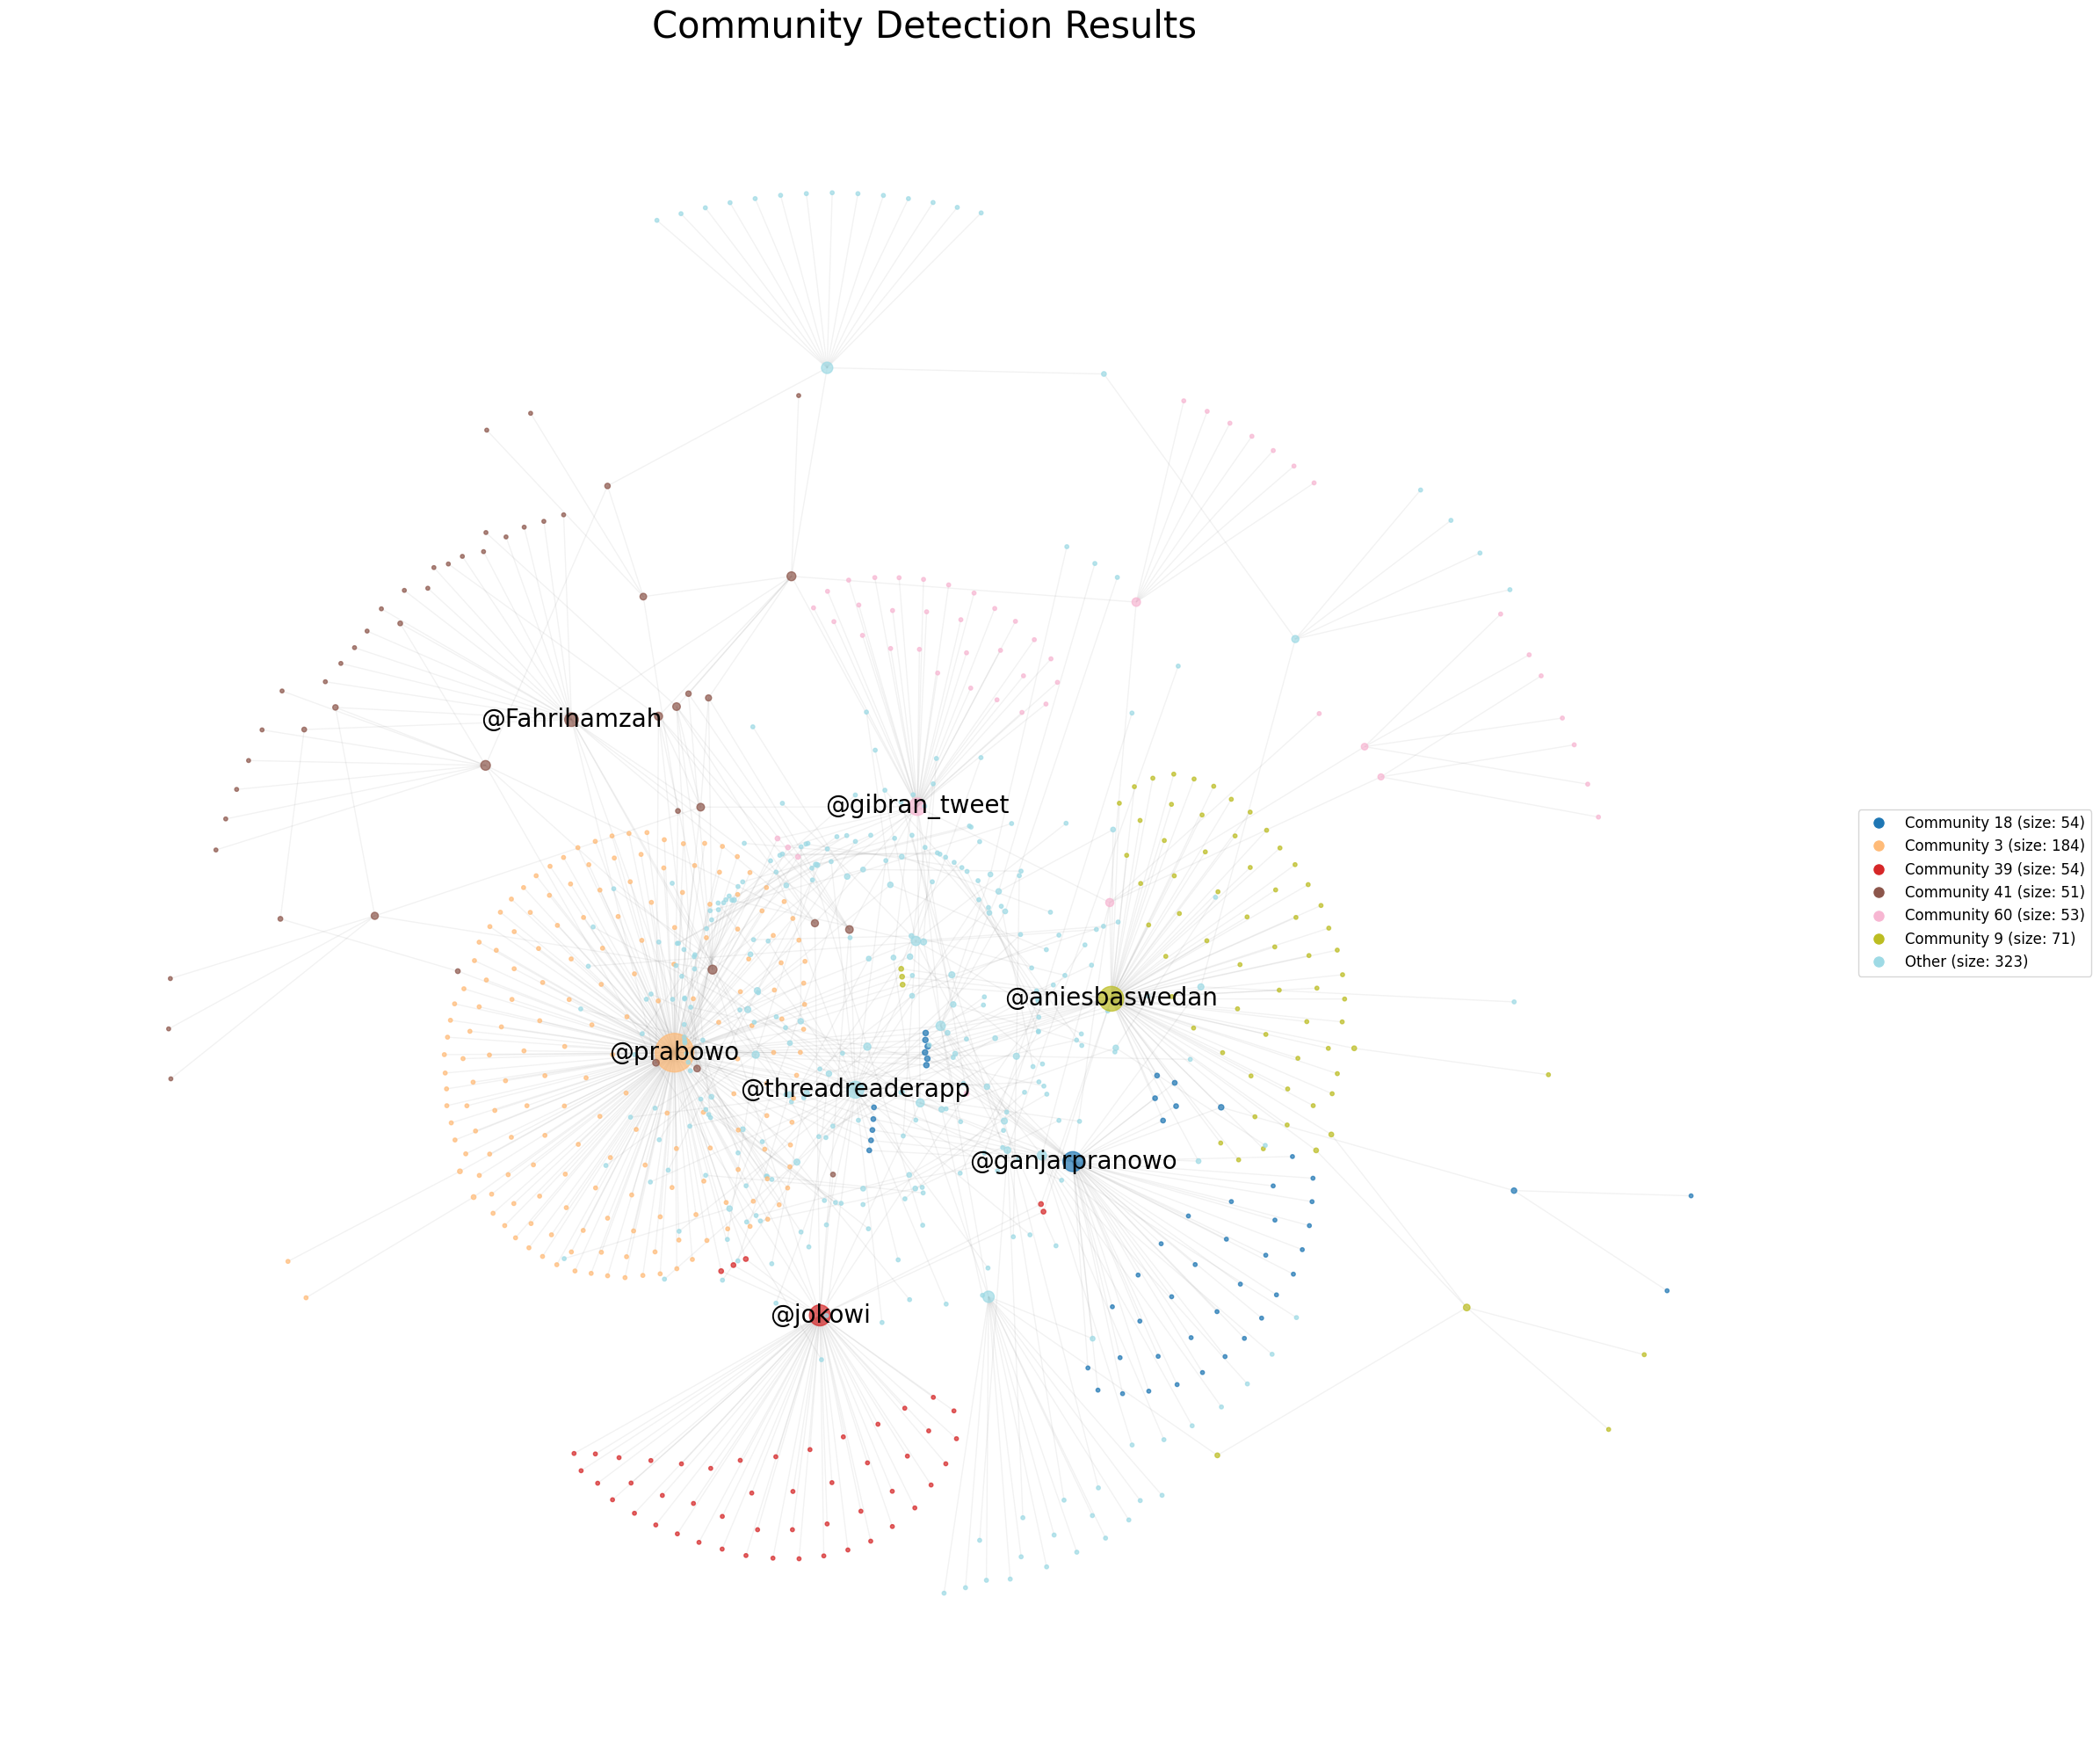

In [ ]:
# Visualization
def get_node_size(G, min_size=10, max_size=1000):
    degrees = dict(G.degree())
    min_degree, max_degree = min(degrees.values()), max(degrees.values())
    return {node: min_size + (max_size - min_size) * (deg - min_degree) / (max_degree - min_degree)
            for node, deg in degrees.items()}

def get_color_map(communities):
    unique_communities = list(set(communities.values()))
    unique_communities.sort(key=lambda x: str(x))
    color_map = plt.cm.tab20(np.linspace(0, 1, len(unique_communities)))
    return {comm: color_map[i] for i, comm in enumerate(unique_communities)}

node_sizes = get_node_size(G)
color_map = get_color_map(new_community_labels)
node_colors = [color_map[new_community_labels[node]] for node in G.nodes()]

community_sizes = Counter(new_community_labels.values())

plt.figure(figsize=(24, 20))
pos = nx.kamada_kawai_layout(G)
nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='gray')
nx.draw_networkx_nodes(G, pos, node_size=[node_sizes[node] for node in G.nodes()],
                       node_color=node_colors, alpha=0.7)
large_nodes = [node for node, size in node_sizes.items() if size > 100]
nx.draw_networkx_labels(G, pos, {node: node for node in large_nodes}, font_size=20)

plt.title("Community Detection Results ", fontsize=30)

unique_communities = list(set(new_community_labels.values()) - {'Other'})
unique_communities.sort(key=lambda x: str(x))
legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                   label=f'Community {i} (size: {community_sizes[i]})',
                   markerfacecolor=color_map[i], markersize=10)
                   for i in unique_communities]
if 'Other' in new_community_labels.values():
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                           label=f'Other (size: {community_sizes["Other"]})',
                           markerfacecolor=color_map['Other'], markersize=10))

plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

## USING Model GNN GRAPH SAGE + LOUVEN

In [ ]:
# Buat graph
G = nx.Graph()
for _, row in mention_df.iterrows():
    G.add_edge(row['username'], row['content_username'])

# Konversi graph ke format PyTorch Geometric
node_mapping = {node: i for i, node in enumerate(G.nodes())}
edge_index = torch.tensor([[node_mapping[u], node_mapping[v]] for u, v in G.edges()]).t().contiguous()
x = torch.eye(len(G.nodes()))  # Fitur node sederhana (one-hot encoding)

data = Data(x=x, edge_index=edge_index)
class GraphSAGE(torch.nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(num_features, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# Pelatihan model
hidden_dim = 64
num_classes = 16  # Jumlah dimensi embedding
model = GraphSAGE(num_features=data.num_features, hidden_dim=hidden_dim, num_classes=num_classes)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = F.mse_loss(out, torch.randn_like(out))  # Unsupervised loss
    loss.backward()
    optimizer.step()
    return loss

# Training loop
for epoch in range(200):
    loss = train()
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

Epoch 0, Loss: 0.9921
Epoch 10, Loss: 0.9866
Epoch 20, Loss: 0.9993
Epoch 30, Loss: 1.0151
Epoch 40, Loss: 1.0030
Epoch 50, Loss: 0.9815
Epoch 60, Loss: 0.9902
Epoch 70, Loss: 0.9912
Epoch 80, Loss: 1.0210
Epoch 90, Loss: 1.0006
Epoch 100, Loss: 0.9966
Epoch 110, Loss: 0.9927
Epoch 120, Loss: 1.0188
Epoch 130, Loss: 0.9918
Epoch 140, Loss: 0.9890
Epoch 150, Loss: 1.0194
Epoch 160, Loss: 0.9824
Epoch 170, Loss: 0.9772
Epoch 180, Loss: 0.9856
Epoch 190, Loss: 1.0061


In [ ]:
# Generate node embeddings
model.eval()
with torch.no_grad():
    node_embeddings = model(data).numpy()

# Konversi embeddings kembali ke dictionary dengan username
username_embeddings = {node: node_embeddings[i] for node, i in node_mapping.items()}

# Buat graph baru dengan embeddings sebagai node attributes
G_embedded = nx.Graph()
for node, embedding in username_embeddings.items():
    G_embedded.add_node(node, embedding=embedding)
for edge in G.edges():
    G_embedded.add_edge(*edge)

# Deteksi komunitas menggunakan Louvain
louvain_communities_result = louvain_communities(G_embedded, weight='embedding', resolution=1.0)

# Konversi hasil Louvain ke format yang diinginkan
community_labels = {}
for i, community in enumerate(louvain_communities_result):
    for node in community:
        community_labels[node] = i

def remove_small_communities(community_labels, min_size=50):
    community_sizes = defaultdict(int)
    for node, comm in community_labels.items():
        community_sizes[comm] += 1

    large_communities = {comm for comm, size in community_sizes.items() if size >= min_size}

    new_community_labels = {}
    for node, comm in community_labels.items():
        if comm in large_communities:
            new_community_labels[node] = comm
        else:
            new_community_labels[node] = 'Other'

    return new_community_labels

# Gunakan fungsi
new_community_labels = remove_small_communities(community_labels, min_size=50)

### VISUALIZATION COMMUNITY GNN GRAPH SAGE + LOUVEN

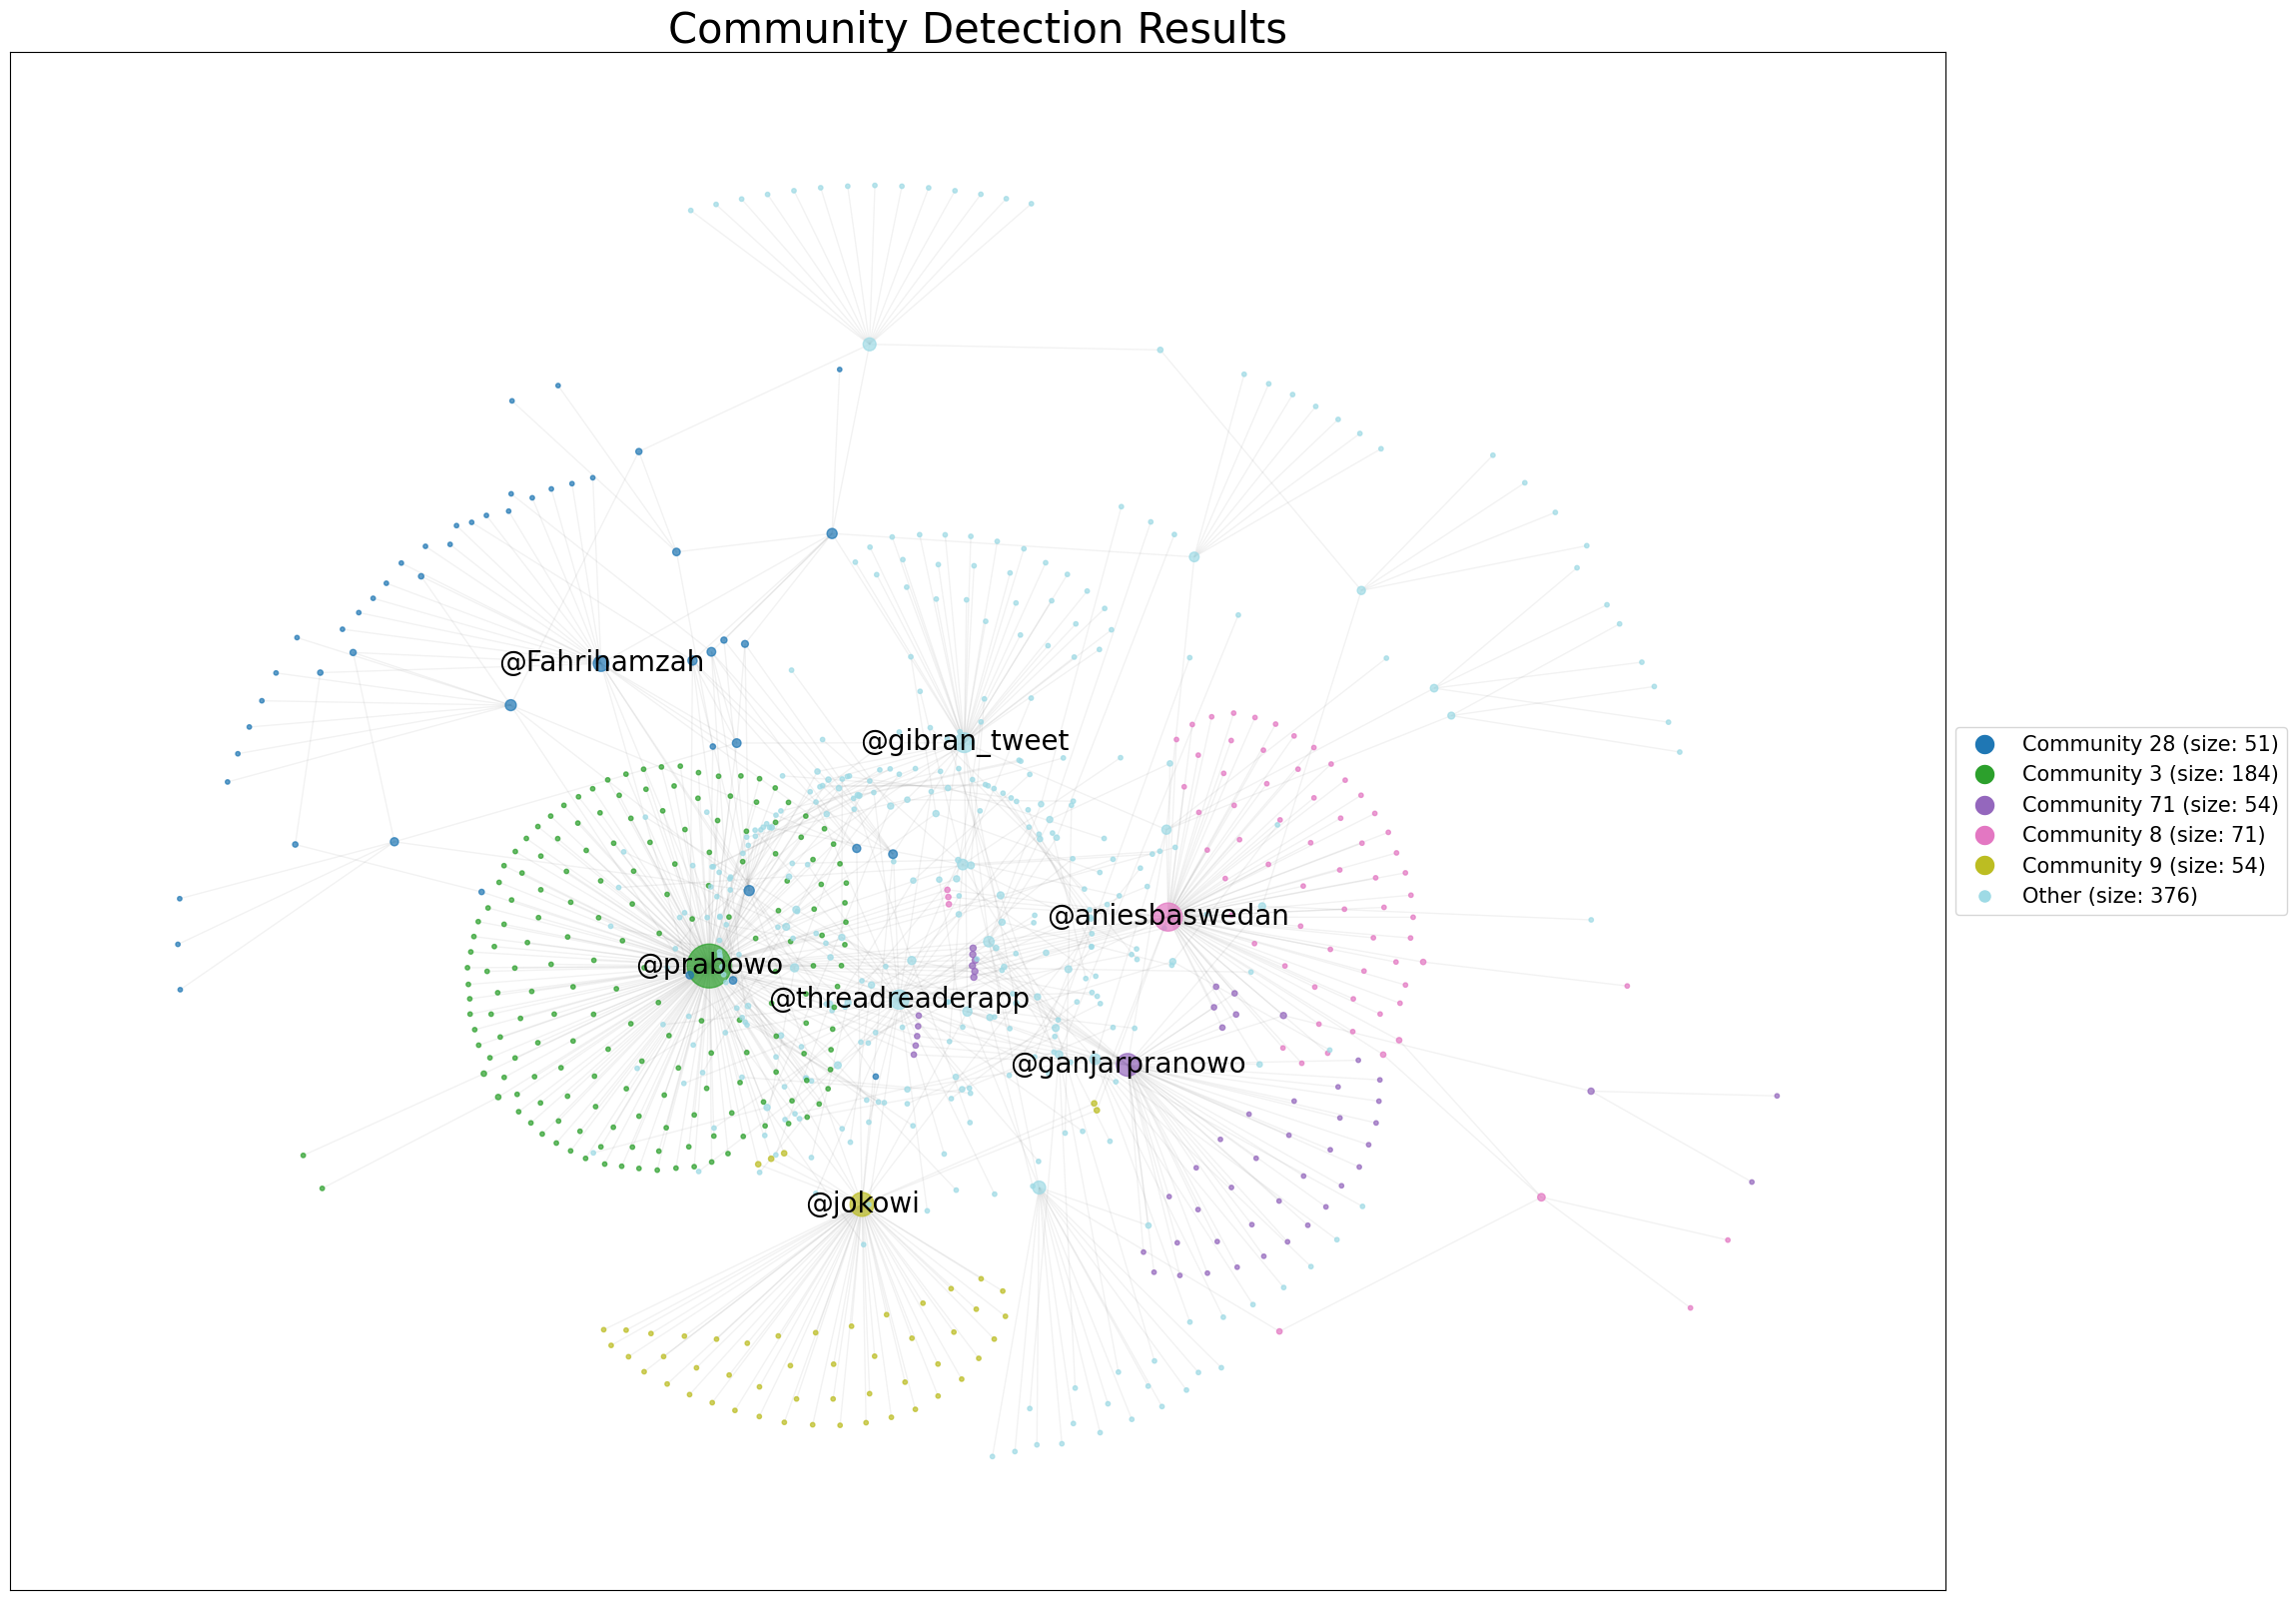

In [ ]:
# Fungsi untuk mengatur ukuran node berdasarkan degree
def get_node_size(G, min_size=10, max_size=1000):
    degrees = dict(G.degree())
    min_degree, max_degree = min(degrees.values()), max(degrees.values())
    return {node: min_size + (max_size - min_size) * (deg - min_degree) / (max_degree - min_degree)
            for node, deg in degrees.items()}

# Fungsi untuk mendapatkan warna berdasarkan komunitas
def get_color_map(communities):
    unique_communities = list(set(communities.values()))
    # Urutkan komunitas, ubah ke string untuk menghindari masalah perbandingan
    unique_communities.sort(key=lambda x: str(x))
    color_map = plt.cm.tab20(np.linspace(0, 1, len(unique_communities)))
    return {comm: color_map[i] for i, comm in enumerate(unique_communities)}

# Persiapan data
node_sizes = get_node_size(G)
color_map = get_color_map(new_community_labels)
node_colors = [color_map[new_community_labels[node]] for node in G.nodes()]

# Hitung ukuran komunitas
community_sizes = Counter(new_community_labels.values())

# Visualisasi graph
plt.figure(figsize=(25, 20))

# Gunakan Kamada-Kawai layout
pos = nx.kamada_kawai_layout(G)

# Gambar edges
nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='gray')

# Gambar nodes
nx.draw_networkx_nodes(G, pos, node_size=[node_sizes[node] for node in G.nodes()],
                       node_color=node_colors, alpha=0.7)

# Tambahkan label untuk node-node besar
large_nodes = [node for node, size in node_sizes.items() if size > 100]  # Meningkatkan threshold
nx.draw_networkx_labels(G, pos, {node: node for node in large_nodes}, font_size=20)

# Tambahkan judul
plt.title("Community Detection Results", fontsize=30)

# Buat legenda
unique_communities = list(set(new_community_labels.values()) - {'Other'})
unique_communities.sort(key=lambda x: str(x))  # Urutkan komunitas
legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                   label=f'Community {i} (size: {community_sizes[i]})',
                   markerfacecolor=color_map[i], markersize=15)
                   for i in unique_communities]
# Tambahkan 'Other' ke legenda jika ada
if 'Other' in new_community_labels.values():
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                           label=f'Other (size: {community_sizes["Other"]})',
                           markerfacecolor=color_map['Other'], markersize=10))

plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=15)


## **MODEL EVALUATION**
- Modularity
- Coverage
- Conductance

In [ ]:
#Modularity
from networkx.algorithms.community import modularity

# Group nodes by their community ID
communities = []
for comm_id in set(new_community_labels.values()):
    community = [node for node, label in new_community_labels.items() if label == comm_id]
    communities.append(community)

modularity_score = modularity(G, communities)
print(f"Modularity: {modularity_score:.4f}")

Modularity: 0.6641


In [ ]:
# Coverage

# Create an example graph
G = nx.karate_club_graph()

# Perform Louvain community detection
partition = community_louvain.best_partition(G)
louvain_communities_result = {}
for node, community in partition.items():
    if community not in louvain_communities_result:
        louvain_communities_result[community] = []
    louvain_communities_result[community].append(node)

# Convert louvain_communities_result to a list of sets
louvain_communities_result = [set(nodes) for nodes in louvain_communities_result.values()]

# Coverage calculation function
def calculate_coverage(G, communities):
    internal_edges = sum(G.subgraph(c).number_of_edges() for c in communities)
    total_edges = G.number_of_edges()
    return internal_edges / total_edges

# Calculate and print coverage
coverage = calculate_coverage(G, louvain_communities_result)
print(f"Coverage: {coverage:.4f}")

Coverage: 0.7564


In [ ]:
# Conductance
from networkx.algorithms.cuts import conductance

def average_conductance(G, communities):
    conductances = []
    for community in communities:
        if len(community) < len(G) - 1:  # Ignore communities that are the entire graph
            comm_conductance = conductance(G, community)
            conductances.append(comm_conductance)
    return np.mean(conductances)

avg_conductance = average_conductance(G, louvain_communities_result)
print(f"Average Conductance: {avg_conductance:.4f}")


Average Conductance: 0.0148


### **Statistics Description**

In [ ]:
# Analisis statistik deskriptif komunitas

print("Statistik Deskriptif Komunitas:")
print(f"Jumlah komunitas: {len(community_sizes)}")
print(f"Ukuran komunitas rata-rata: {sum(community_sizes.values()) / len(community_sizes):.2f}")
print(f"Ukuran komunitas terbesar: {max(community_sizes.values())}")
print(f"Ukuran komunitas terkecil: {min(community_sizes.values())}")

# Tambahkan informasi tentang graph
print(f"Jumlah node: {G.number_of_nodes()}")
print(f"Jumlah edge: {G.number_of_edges()}")
print(f"Jumlah komunitas: {len(unique_communities)}")

Statistik Deskriptif Komunitas:
Jumlah komunitas: 6
Ukuran komunitas rata-rata: 131.67
Ukuran komunitas terbesar: 376
Ukuran komunitas terkecil: 51
Jumlah node: 790
Jumlah edge: 812
Jumlah komunitas: 5


In [ ]:
# Print komunitas untuk setiap username
for username, community in new_community_labels.items():
    print(f"Username: {username}, Community: {community}")

Username: @ajengcute16__, Community: Other
Username: @Oo1kRcEl7heMLC1tzrvQGi0fA61b8RExoMj1Mnv2FGo=, Community: Other
Username: @3hU1DIZOqI1rtkLzvofq6+XnZ6fx3QErNM0O6uwIClw=, Community: Other
Username: @ziN/gFl6zKDytA0oSQcm1XEY7bIlyXQQPGoMyKY6bTw=, Community: Other
Username: @2R9XexRCm3Rfb2F/+Y0YbFECiH5bAex29qTgs4g/3iA=, Community: Other
Username: @6hhHh7FRoSMPmPoumThVdRnWGkgMqiOMIA9TxBMcYJc=, Community: Other
Username: @R1aOTkxhRMalqz9OuB849qSz615vwEy+5eW1ZYThnwU=, Community: Other
Username: @ZdONPUd69hX8bg6AQ3iEq4YhobcoUZviZXbXyJ4hKJc=, Community: Other
Username: @DqkFEgIKQ01RWDWKR4cEc/RJbxtNY3CNQ1RdvzPU4ZE=, Community: Other
Username: @tBPMLrtmzGF7Rin8O8xxHuzWHzmA48QqvlItG0mD3W0=, Community: Other
Username: @cOybCwV0mWQzjSGK2rrhcWEDIzbWQtRibNHznkA2a5s=, Community: Other
Username: @H/7nUeCfR/ABTrN65JX/eNl1n3RdVMSgnabrII+rdg8=, Community: Other
Username: @3NXMUUl6gd4QOgqiwtpUo5/gztvpWDujFtRJzZMyekU=, Community: Other
Username: @icFhFGWJHItvwBfEU6pibCV51/9v5A8kriGw/ivDIag=, Community: O

## **TOP INFLUENCE**
berdasarkan
- flw_cnt > 1000000
- lst_cnt > 10000
- number of retweet >100

In [ ]:
# Identifikasi komunitas
top_communities = community_sizes.most_common(10)
print("\nKomunitas:")
for i, (community, size) in enumerate(top_communities, 1):
    print(f"{i}. Komunitas {community}: {size} anggota")# Set to track already selected influencers
selected_influencers = set()

for i, (community, _) in enumerate(top_communities, 1):
    users_in_community = [node for node, comm in new_community_labels.items() if comm == community]

    # Filter akun berdasarkan batasan yang diberikan
    influencers = mention_df[(mention_df['username'].isin(users_in_community)) |
                             (mention_df['flw_cnt'] > 1000000) |
                             (mention_df['lst_cnt'] > 10000) |
                             (mention_df['num_retweets'] > 100)]\
                    .drop_duplicates(subset=['username'])\
                    .sort_values(['flw_cnt', 'lst_cnt', 'num_retweets'], ascending=[False, False, False])

    # Exclude already selected influencers
    influencers = influencers[~influencers['username'].isin(selected_influencers)].head(5)

    # Update the set of selected influencers
    selected_influencers.update(influencers['username'])

    print(f"\nTop 5 Influencer dalam Komunitas {community}:")
    for _, influencer in influencers.iterrows():
        print(f"{influencer['username']}: {influencer['flw_cnt']} pengikut, {influencer['frn_cnt']} friend, {influencer['lst_cnt']} daftar, {influencer['num_retweets']} retweet")



Komunitas:
1. Komunitas Other: 376 anggota
2. Komunitas 3: 184 anggota
3. Komunitas 8: 71 anggota
4. Komunitas 9: 54 anggota
5. Komunitas 71: 54 anggota
6. Komunitas 28: 51 anggota

Top 5 Influencer dalam Komunitas Other:
@1NMk1QxaKOtKppb2hOv106OpMDLKCYcIFHR5CN4AXcw=: 11057736.0 pengikut, 34.0 friend, 11030.0 daftar, 0 retweet
@RR3gSQhj6HMd0kwJZ0+ff9CD0ZzUX+eFwkA4FxyRxg4=: 11057707.0 pengikut, 33.0 friend, 11032.0 daftar, 0 retweet
@reOZgh2AILDxjrUT/9BIfeWP8MoQxwaHw2no2G61LBY=: 11056663.0 pengikut, 33.0 friend, 11035.0 daftar, 0 retweet
@yrWivE/TXu2+66YwWc8VqrXoheLAtXvpwuwbWv3s/Fw=: 11056663.0 pengikut, 33.0 friend, 11035.0 daftar, 0 retweet
@X9EG8XExT6AnzbUL2KquGso9/gozzqsRHOPi+DGSZIk=: 11055708.0 pengikut, 33.0 friend, 11035.0 daftar, 6 retweet

Top 5 Influencer dalam Komunitas 3:
@/B0rfjO+rJkNUmvMlK3kJVdeJ6kXQ4jCBHwh0jFmWoY=: 11055707.0 pengikut, 33.0 friend, 11035.0 daftar, 1 retweet
@2R9XexRCm3Rfb2F/+Y0YbFECiH5bAex29qTgs4g/3iA=: 11055683.0 pengikut, 33.0 friend, 11035.0 daftar, 0

## SAVING DATA

In [ ]:
# 1. Membuat data baru dengan menambahkan kolom komunitas
new_df = mention_df.copy()
new_df['community'] = new_df['username'].map(new_community_labels)

In [ ]:
data = new_df.drop_duplicates(subset='username', keep='first')

In [ ]:
data.head()

,username,tcode,num_retweets,frn_cnt,flw_cnt,sts_cnt,lst_cnt,content,content_username,community
222,@OX60RXOcgDFKMkSMmoL737CJP/SBCrojDaVqM7LG0iI=,rt,48,2132.0,2125.0,106994.0,0.0,RT Calon presiden nomor urut 1 Anies Baswedan(...,@aniesbaswedan,0
307,@1JcYpkShzGn5XgsafYzVwPhpCOC3AlqyfRJ3taWDYv8=,rt,48,580.0,245.0,83318.0,0.0,RT Calon presiden nomor urut 1 Anies Baswedan(...,@aniesbaswedan,0
887,@l5mIiXsGKblzDcrscZ0hJjVmkSP0Nj2K7KJcL+hDLqY=,rt,55,4680.0,2613.0,5630.0,5.0,RT ð¤ Mana pendukung ganjar suaranya mari me...,@ganjarpranowo,1
920,@8WTBCY5w7foMhyLKz63oJmxqttJL/XcBPizytRHVQgg=,rt,48,997.0,96.0,3322.0,0.0,RT Calon presiden nomor urut 1 Anies Baswedan(...,@aniesbaswedan,0
1582,@KDQq6lQEQ7HFwv2MKiiso2lCjV4Dri/Z72jb6TtH/AE=,rt,163,117.0,71.0,13197.0,0.0,RT Capres Nomor Urut Satu Anies Baswedan (@ani...,@aniesbaswedan,0


In [ ]:
data['community'].value_counts()

0        3970
Other    3681
4        1597
1        1414
82       1091
49        469
Name: community, dtype: int64

In [ ]:
data.to_csv(r'D:\Lomba-Lomba\BDC Satria Data 2024\SEMIFINAL\data\GCL+LAUVAIN.csv', index=False)

### **BOT DETECTION**

FRN_CNT_THRESHOLD: Threshold atau batas untuk jumlah teman (following) yang dimiliki oleh pengguna. Jika pengguna memiliki jumlah teman lebih dari nilai ini dan jumlah pengikut kurang dari threshold pengikut, pengguna tersebut dianggap bot.

FLW_CNT_THRESHOLD: Threshold untuk jumlah pengikut (followers) yang dimiliki oleh pengguna. Jika pengguna memiliki jumlah pengikut kurang dari nilai ini dan jumlah teman lebih dari threshold teman, pengguna tersebut dianggap bot.

STS_CNT_THRESHOLD: Threshold untuk jumlah status atau tweet yang telah dibuat oleh pengguna. Jika pengguna memiliki jumlah status lebih dari nilai ini, pengguna tersebut dianggap bot.

In [ ]:
# Menentukan threshold untuk deteksi bot
FRN_CNT_THRESHOLD = 5000  # Threshold jumlah teman
FLW_CNT_THRESHOLD = 1   # Threshold jumlah pengikut
STS_CNT_THRESHOLD = 10000 # Threshold jumlah status

# Fungsi untuk menentukan apakah pengguna adalah bot atau bukan
def is_bot(row):
    if row['frn_cnt'] > FRN_CNT_THRESHOLD and row['flw_cnt'] < FLW_CNT_THRESHOLD:
        return 1  # Bot
    if row['sts_cnt'] > STS_CNT_THRESHOLD:
        return 1  # Bot
    if row['frn_cnt'] > 1000 * row['flw_cnt']:
        return 1  # Bot
    return 0  # Bukan Bot

In [ ]:
# Menerapkan fungsi ke setiap baris di DataFrame
data['is_bot'] = data.apply(is_bot, axis=1)

In [ ]:
data['is_bot'].value_counts()

is_bot
1    6461
0    5625
Name: count, dtype: int64

# **SENTIMEN ANALYSIS**

In [ ]:
data = pd.read_csv('/content/gdrive/My Drive/BDC-SatriaData-2024/SEMIFINAL/GraphSAGE+Louvain All.csv')
data.head()

### DROP DUPLICATE

In [ ]:
# prompt: drop duplicate data based on username
data = data.drop_duplicates(subset='username', keep='first')

In [ ]:
# ENCODE
data['community'] = data['community'].replace({
      '2': 1,
      'Other': 2,
      '32': 3,
      '3': 4,
      '75': 5,
      '40': 6
})

In [ ]:
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string

In [ ]:
def preprocess_text(text):
    # Casefolding: mengubah teks menjadi lowercase
    text = text.lower()

    # Menghapus kata rt di depan kalimat
    text = re.sub(r'\brt\b', '', text)

    # Menghapus [re ...] di dalam teks
    text = re.sub(r'\[re\s[^\]]+\]', '', text)

    # Menghapus username dengan pola yang diberikan
    text = re.sub(r'@[A-Za-z0-9_]+[A-Za-z0-9_+/=]*', '', text)

    # Menghapus URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Menghapus hashtag dan kata setelahnya
    text = re.sub(r'#\w+', '', text)

    # Menghapus karakter emoji
    text = text.encode('ascii', 'ignore').decode('ascii')

    # Menghapus angka
    text = re.sub(r'\d+', '', text)

    # Menghapus whitespace berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    # Menghapus tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenisasi
    tokens = word_tokenize(text)

    # Menghapus stopwords dalam bahasa Indonesia
    stop_words = set(stopwords.words('indonesian'))
    tokens = [word for word in tokens if word not in stop_words]

    # Menggabungkan kembali token menjadi teks
    cleaned_text = ' '.join(tokens)

    return cleaned_text

In [ ]:
data['cleaned_content'] = data['content'].apply(preprocess_text)

### CLEAN DATA WITH NO TEXT

In [ ]:
# prompt: find sum row with no content_cleaned, example ''. after hat drop from data

data_cleaned = data[data['cleaned_content'] != '']
data_cleaned.shape[0]

### **PELABELAN PASLON**

In [ ]:
import pandas as pd
from transformers import pipeline
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from collections import Counter

In [ ]:
def classify_paslon(text):
    text = text.lower()

    # Kata kunci untuk setiap paslon
    paslon1_keywords = ['anies', 'muhaimin', 'amin', 'nasdem', 'pks', 'pkb', '@aniesbaswedan', '@cakiminow', '@nasdem', '@tomlembong', '01', 'paslon 1']
    paslon2_keywords = ['prabowo', 'subianto', 'gibran', 'gerindra', 'golkar', 'pan', 'ppp', 'demokrat', '@prabowo', '@gibran_tweet', '@gerindra', '@muzanigerindra', '@fraksi_gerindra', '@bobbynasution_', '02', 'menhan', 'paslon 2', 'gemoy', 'omon']
    paslon3_keywords = ['ganjar', 'mahfud', 'pdi-p', 'pdi perjuangan', 'pdip', 'hanura', 'perindo', '@ganjarpranowo', '@pdi_perjuangan', '03', 'paslon 3']

    # Fungsi untuk memeriksa keberadaan kata kunci
    def contains_keyword(keywords):
        return any(keyword in text or f"@{keyword}" in text for keyword in keywords)

    if contains_keyword(paslon1_keywords):
        return 'Paslon 1'
    elif contains_keyword(paslon2_keywords):
        return 'Paslon 2'
    elif contains_keyword(paslon3_keywords):
        return 'Paslon 3'
    else:
        return 'Tidak Terkait'

In [ ]:
# Terapkan fungsi ke DataFrame
data_cleaned['paslon'] = data_cleaned['content'].apply(classify_paslon)

In [ ]:
# prompt: drop data with value paslon = Tidak Terkait
data_cleaned = data_cleaned[data_cleaned['paslon'] != 'Tidak Terkait']
data_cleaned.shape

### **PELABELAN SENTIMEN**

In [ ]:
def classify_long_content_pipeline(content,classification):
    # Define chunk size and stride
    chunk_size = 512
    stride = 256

    # Helper function to classify a single chunk
    def classify_chunk(chunk):
        result = classification([chunk])
        if result:
            result = result[0]
            score = result.get('score', 0)  # Extract the score from the dictionary or default to 0
            label = result.get('label', 'UNKNOWN')  # Extract the label from the dictionary or default to 'UNKNOWN'
            return score, label
        return 0, 'UNKNOWN'

    # Check if the content length is shorter than the chunk size
    if len(content) <= chunk_size:
        return classify_chunk(content)

    # Split the content into overlapping chunks
    chunks = []
    for i in range(0, len(content), stride):
        chunk = content[i:i + chunk_size]
        if len(chunk) < chunk_size and i + chunk_size > len(content):
            chunk = content[i:]  # Take the remaining part of the content
        chunks.append(chunk)

    # Classify each chunk using the sentiment analysis pipeline
    chunk_results = []
    for chunk in chunks:
        score, label = classify_chunk(chunk)
        chunk_results.append((score, label))

    # Check if chunk_results is empty
    if not chunk_results:
        return None  # Return None if no chunks were generated or no scores were returned

    # # Calculate final score and determine final label
    # weighted_sum = sum(label_to_value[label] * score for score, label in chunk_results)
    # total_weight = sum(score for score, label in chunk_results)
    # final_score = weighted_sum / total_weight if total_weight != 0 else 0

    # # Determine the final label based on the sign of the final_score
    # final_label = 'POSITIVE' if final_score > 0 else 'NEGATIVE'
    total_score = sum(score for score, label in chunk_results)
    final_score = total_score / len(chunk_results)

    # Determine the most frequent label
    labels = [label for score, label in chunk_results]
    label_counter = Counter(labels)
    final_label = label_counter.most_common(1)[0][0]

    return final_score, final_label

In [ ]:
# Fungsi untuk melakukan pra-pemrosesan skor sentimen
def preprocess_sentiment_score(df):
    model_name = "lxyuan/distilbert-base-multilingual-cased-sentiments-student"
    classifier = pipeline('sentiment-analysis', model=model_name)
    content = df['cleaned_content'].to_numpy()

    content_scores = []
    for content in tqdm(content, desc="Processing content sentiment score", unit="content"):
        content_scores.append(classify_long_content_pipeline(content, classifier))

    df['sentiment_score'] = [x[0] for x in content_scores]
    df['sentiment_label'] = [x[1] for x in content_scores]

    label_to_weight = {'negative': 0.5, 'neutral': 1.0, 'positive': 1.5}
    # Skala skor sentimen berdasarkan bobot
    df['weighted_sentiment_score'] = df.apply(
        lambda row: row['sentiment_score'] * label_to_weight[row['sentiment_label']], axis=1)

    # Normalisasi skor sentimen berbobot ke rentang 0.00 hingga 5.00
    min_score = df['weighted_sentiment_score'].min()
    max_score = df['weighted_sentiment_score'].max()
    df['normalized_weighted_sentiment_score'] = df['weighted_sentiment_score'].apply(
        lambda x: 5.00 * (x - min_score) / (max_score - min_score))

    df['normalized_weighted_sentiment_score'] = df['normalized_weighted_sentiment_score'].apply(
        lambda x: round(x * 2) / 2)

    return df

In [ ]:
df = data_cleaned.copy()

In [ ]:
# Proses sentimen dengan pipeline
df = preprocess_sentiment_score(df)

Processing content sentiment score: 100%|██████████| 12086/12086 [51:43<00:00,  3.89content/s]


In [ ]:
df = df[['username', 'content', 'cleaned_content', 'tcode', 'community', 'paslon', 'is_bot', 'sentiment_label']]

In [ ]:
df.head()

,username,content,cleaned_content,tcode,community,paslon,sentiment_label
0,@OX60RXOcgDFKMkSMmoL737CJP/SBCrojDaVqM7LG0iI=,RT Calon presiden nomor urut 1 Anies Baswedan(...,calon presiden nomor urut anies baswedan menye...,rt,0,Paslon 1,negative
1,@1JcYpkShzGn5XgsafYzVwPhpCOC3AlqyfRJ3taWDYv8=,RT Calon presiden nomor urut 1 Anies Baswedan(...,calon presiden nomor urut anies baswedan menye...,rt,0,Paslon 1,negative
2,@l5mIiXsGKblzDcrscZ0hJjVmkSP0Nj2K7KJcL+hDLqY=,RT ð¤ Mana pendukung ganjar suaranya mari me...,pendukung ganjar suaranya mari merapat wooyyg ...,rt,1,Paslon 3,positive
3,@8WTBCY5w7foMhyLKz63oJmxqttJL/XcBPizytRHVQgg=,RT Calon presiden nomor urut 1 Anies Baswedan(...,calon presiden nomor urut anies baswedan menye...,rt,0,Paslon 1,negative
4,@KDQq6lQEQ7HFwv2MKiiso2lCjV4Dri/Z72jb6TtH/AE=,RT Capres Nomor Urut Satu Anies Baswedan (@ani...,capres nomor urut anies baswedan disambut ribu...,rt,0,Paslon 1,positive


In [ ]:
df['sentiment_label'].value_counts()

sentiment_label
negative    8273
positive    3810
neutral        3
Name: count, dtype: int64

In [ ]:
df['paslon'].value_counts()

paslon
Paslon 1    7808
Paslon 2    3848
Paslon 3     430
Name: count, dtype: int64

In [ ]:
df['is_bot'].value_counts()

is_bot
1    6461
0    5625
Name: count, dtype: int64

In [ ]:
# prompt: print 3 sample from content with sentiment=Positif

positive_samples = df[df['sentiment_label'] == 'positive']
for i in range(3):
  print(f"Sample {i+1}: {positive_samples['cleaned_content'].iloc[i]}")

Sample 1: pendukung ganjar suaranya mari merapat wooyyg diblng pendukung bokepbodo aja yg terbaik menangkan gama gaspoll
Sample 2: capres nomor urut anies baswedan disambut ribuan warga menghadiri pagelaran seni wayang kulit ponorogo jawa timur muhaimin iskandar cak imin mengunjungi pengrajin gamelan magetan jawa timur
Sample 3: capres nomor urut anies baswedan disambut ribuan warga menghadiri pagelaran seni wayang kulit ponorogo jawa timur muhaimin iskandar cak imin mengunjungi pengrajin gamelan magetan jawa timur


In [ ]:
negative_samples = df[df['sentiment_label'] == 'negative']
for i in range(3):
  print(f"Sample {i+1}: {negative_samples['cleaned_content'].iloc[i]}")

Sample 1: calon presiden nomor urut anies baswedan menyebut tantangan misi perubahan seberat beban hidup dipikul rumah tangga anak muda
Sample 2: calon presiden nomor urut anies baswedan menyebut tantangan misi perubahan seberat beban hidup dipikul rumah tangga anak muda
Sample 3: calon presiden nomor urut anies baswedan menyebut tantangan misi perubahan seberat beban hidup dipikul rumah tangga anak muda


In [ ]:
df.to_csv('./Data Analisis Sentimen.csv', index=False)

## **PEMILIHAN DATA**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Bidirectional, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import plot_model

In [ ]:
df = pd.read_csv('./Data Analisis Sentimen.csv')
df.head()

,username,content,cleaned_content,tcode,community,paslon,is_bot,sentiment_label
0,@OX60RXOcgDFKMkSMmoL737CJP/SBCrojDaVqM7LG0iI=,RT Calon presiden nomor urut 1 Anies Baswedan(...,calon presiden nomor urut anies baswedan menye...,rt,1,Paslon 1,1,negative
1,@1JcYpkShzGn5XgsafYzVwPhpCOC3AlqyfRJ3taWDYv8=,RT Calon presiden nomor urut 1 Anies Baswedan(...,calon presiden nomor urut anies baswedan menye...,rt,1,Paslon 1,1,negative
2,@l5mIiXsGKblzDcrscZ0hJjVmkSP0Nj2K7KJcL+hDLqY=,RT ð¤ Mana pendukung ganjar suaranya mari me...,pendukung ganjar suaranya mari merapat wooyyg ...,rt,4,Paslon 3,0,positive
3,@8WTBCY5w7foMhyLKz63oJmxqttJL/XcBPizytRHVQgg=,RT Calon presiden nomor urut 1 Anies Baswedan(...,calon presiden nomor urut anies baswedan menye...,rt,1,Paslon 1,0,negative
4,@KDQq6lQEQ7HFwv2MKiiso2lCjV4Dri/Z72jb6TtH/AE=,RT Capres Nomor Urut Satu Anies Baswedan (@ani...,capres nomor urut anies baswedan disambut ribu...,rt,1,Paslon 1,1,positive


In [ ]:
data = df[['username', 'content', 'cleaned_content', 'tcode', 'community', 'paslon', 'is_bot', 'sentiment_label']]
data.head()

,username,content,cleaned_content,tcode,community,paslon,is_bot,sentiment_label
0,@OX60RXOcgDFKMkSMmoL737CJP/SBCrojDaVqM7LG0iI=,RT Calon presiden nomor urut 1 Anies Baswedan(...,calon presiden nomor urut anies baswedan menye...,rt,1,Paslon 1,1,negative
1,@1JcYpkShzGn5XgsafYzVwPhpCOC3AlqyfRJ3taWDYv8=,RT Calon presiden nomor urut 1 Anies Baswedan(...,calon presiden nomor urut anies baswedan menye...,rt,1,Paslon 1,1,negative
2,@l5mIiXsGKblzDcrscZ0hJjVmkSP0Nj2K7KJcL+hDLqY=,RT ð¤ Mana pendukung ganjar suaranya mari me...,pendukung ganjar suaranya mari merapat wooyyg ...,rt,4,Paslon 3,0,positive
3,@8WTBCY5w7foMhyLKz63oJmxqttJL/XcBPizytRHVQgg=,RT Calon presiden nomor urut 1 Anies Baswedan(...,calon presiden nomor urut anies baswedan menye...,rt,1,Paslon 1,0,negative
4,@KDQq6lQEQ7HFwv2MKiiso2lCjV4Dri/Z72jb6TtH/AE=,RT Capres Nomor Urut Satu Anies Baswedan (@ani...,capres nomor urut anies baswedan disambut ribu...,rt,1,Paslon 1,1,positive


In [ ]:
data['content'].iloc[100]

'RT Prabowo Dekat Dengan Ulama, Fadli Zon: Sejak Letkol Sudah Datang ke Kiai NU dan Muhammadiyah â\x81¦@prabowoâ\x81© https://t.co/Q5S7eNR5W4 [RE fadlizon]'

In [ ]:
data['cleaned_content'].iloc[100]

'prabowo ulama fadli zon letkol kiai nu muhammadiyah'

In [ ]:
data = data[data['sentiment_label'] != 'neutral']

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12083 entries, 0 to 12085
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   username         12083 non-null  object
 1   content          12083 non-null  object
 2   cleaned_content  12083 non-null  object
 3   tcode            12083 non-null  object
 4   community        12083 non-null  int64 
 5   paslon           12083 non-null  object
 6   is_bot           12083 non-null  int64 
 7   sentiment_label  12083 non-null  object
dtypes: int64(2), object(6)
memory usage: 849.6+ KB


#### Encoding Label

In [ ]:
label_encoder = LabelEncoder()
data['label_encoded'] = label_encoder.fit_transform(data['sentiment_label'])

In [ ]:
data['label_encoded'].value_counts()

label_encoded
0    8273
1    3810
Name: count, dtype: int64

#### Split Data

In [ ]:
X = data['cleaned_content']
y = data['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
y_train.value_counts()

label_encoded
0    6622
1    3044
Name: count, dtype: int64

In [ ]:
y_test.value_counts()

label_encoded
0    1651
1     766
Name: count, dtype: int64

0 = negatif, 1 = positif.

## **NAIVE BAYES**

#### Pelatihan Model

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# TF-IDF Vektorisasi
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [ ]:
# Menyimpan TF-IDF Vectorizer
joblib.dump(tfidf_vectorizer, './tfidf_vectorizer.pkl')

# Menyimpan Label Encoder
joblib.dump(label_encoder, './label_encoder.pkl')

In [ ]:
# SMOTE dengan TF-IDF
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_tfidf, y_train)

In [ ]:
y_train_resampled.value_counts()

label_encoded
0    6622
1    6622
Name: count, dtype: int64

In [ ]:
# Naive Bayes dengan BernoulliNB
nb_model = BernoulliNB()
nb_model.fit(X_train_resampled, y_train_resampled)

BernoulliNB()

In [ ]:
nb_pred = nb_model.predict(X_test_tfidf)

#### Evaluasi Model

In [ ]:
print("\nClassification Report for Naive Bayes:")
print(classification_report(y_test, nb_pred, digits=4))


Classification Report for Naive Bayes:
              precision    recall  f1-score   support

           0     0.9917    0.7989    0.8849      1651
           1     0.6946    0.9856    0.8149       766

    accuracy                         0.8581      2417
   macro avg     0.8432    0.8923    0.8499      2417
weighted avg     0.8976    0.8581    0.8627      2417



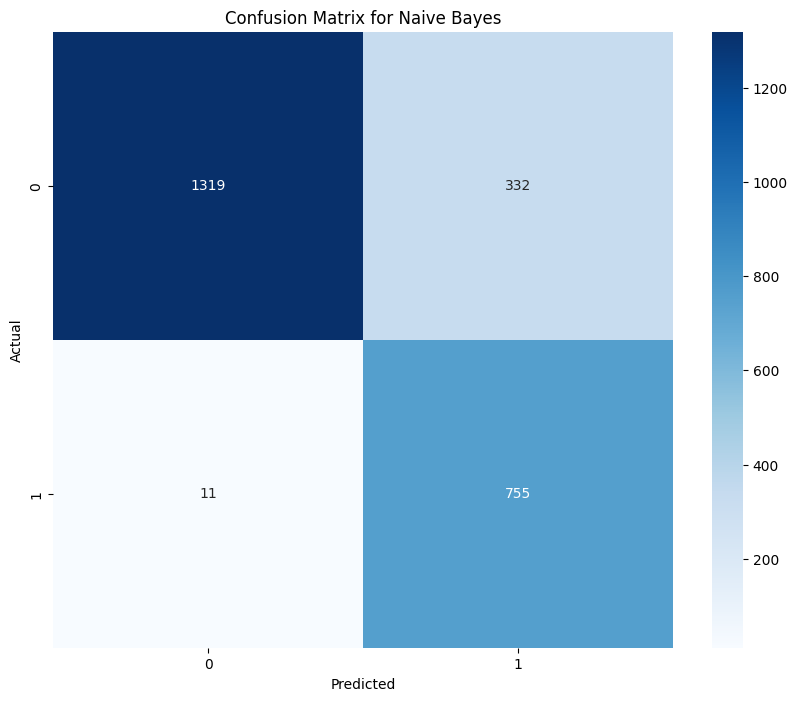

In [ ]:
nb_cm = confusion_matrix(y_test, nb_pred)
plt.figure(figsize=(10,8))
sns.heatmap(nb_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## **SVM**

#### Pelatihan Model

In [ ]:
# SVM
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_resampled, y_train_resampled)

SVC(kernel='linear')

In [ ]:
svm_pred = svm_model.predict(X_test_tfidf)

#### Evaluasi Model

In [ ]:
print("\nClassification Report for SVM:")
print(classification_report(y_test, svm_pred, digits=4))


Classification Report for SVM:
              precision    recall  f1-score   support

           0     0.9749    0.9861    0.9804      1651
           1     0.9692    0.9452    0.9570       766

    accuracy                         0.9731      2417
   macro avg     0.9720    0.9656    0.9687      2417
weighted avg     0.9731    0.9731    0.9730      2417



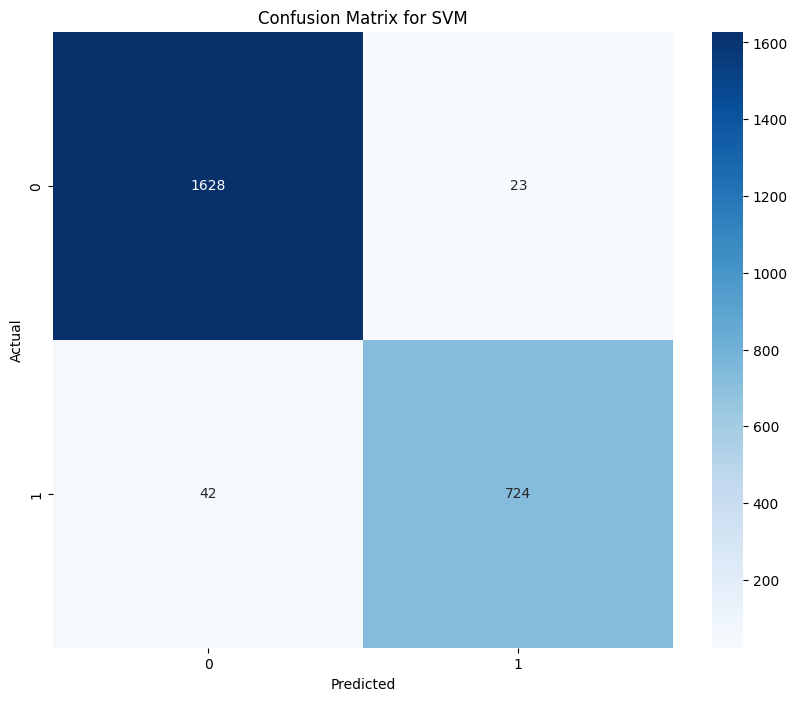

In [ ]:
svm_cm = confusion_matrix(y_test, svm_pred)
plt.figure(figsize=(10,8))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## **SAVE MODEL**

In [ ]:
import joblib

In [ ]:
# Save Naive Bayes model
joblib.dump(nb_model, './nb_model.h5')

# Save SVM model
joblib.dump(svm_model, './svm_model.h5')

## **EDA SENTIMEN**

In [ ]:
data.head()

,username,content,cleaned_content,tcode,community,paslon,is_bot,sentiment_label
0,@OX60RXOcgDFKMkSMmoL737CJP/SBCrojDaVqM7LG0iI=,RT Calon presiden nomor urut 1 Anies Baswedan(...,calon presiden nomor urut anies baswedan menye...,rt,1,Paslon 1,1,negative
1,@1JcYpkShzGn5XgsafYzVwPhpCOC3AlqyfRJ3taWDYv8=,RT Calon presiden nomor urut 1 Anies Baswedan(...,calon presiden nomor urut anies baswedan menye...,rt,1,Paslon 1,1,negative
2,@l5mIiXsGKblzDcrscZ0hJjVmkSP0Nj2K7KJcL+hDLqY=,RT ð¤ Mana pendukung ganjar suaranya mari me...,pendukung ganjar suaranya mari merapat wooyyg ...,rt,4,Paslon 3,0,positive
3,@8WTBCY5w7foMhyLKz63oJmxqttJL/XcBPizytRHVQgg=,RT Calon presiden nomor urut 1 Anies Baswedan(...,calon presiden nomor urut anies baswedan menye...,rt,1,Paslon 1,0,negative
4,@KDQq6lQEQ7HFwv2MKiiso2lCjV4Dri/Z72jb6TtH/AE=,RT Capres Nomor Urut Satu Anies Baswedan (@ani...,capres nomor urut anies baswedan disambut ribu...,rt,1,Paslon 1,1,positive


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12083 entries, 0 to 12085
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   username         12083 non-null  object
 1   content          12083 non-null  object
 2   cleaned_content  12083 non-null  object
 3   tcode            12083 non-null  object
 4   community        12083 non-null  int64 
 5   paslon           12083 non-null  object
 6   is_bot           12083 non-null  int64 
 7   sentiment_label  12083 non-null  object
dtypes: int64(2), object(6)
memory usage: 849.6+ KB


In [ ]:
data['community'].value_counts()

community
1    3958
2    3563
3    1586
4    1416
5    1091
6     469
Name: count, dtype: int64

In [ ]:
data['is_bot'].value_counts()

is_bot
1    6459
0    5624
Name: count, dtype: int64

In [ ]:
data['sentiment_label'].value_counts()

sentiment_label
negative    8273
positive    3810
Name: count, dtype: int64

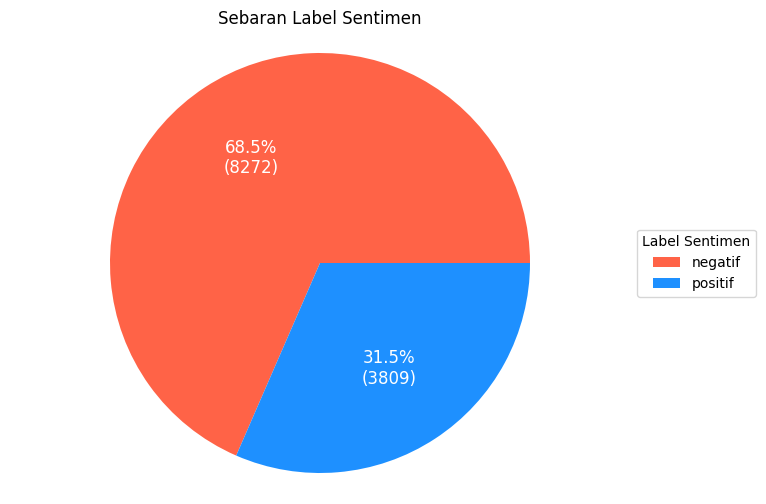

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Data
data_plot1 = {
    'sentiment_label': ['negatif', 'positif'],
    'count': [8273, 3810]
}
sentiment_counts = pd.DataFrame(data_plot1)

# Plotting the pie chart
fig, ax = plt.subplots(figsize=(8, 6))

# Colors
colors = ['#FF6347', '#1E90FF']

# Plot pie chart
wedges, texts, autotexts = ax.pie(sentiment_counts['count'], labels=sentiment_counts['sentiment_label'],
                                  autopct=lambda pct: f'{pct:.1f}%\n({int(pct * sum(sentiment_counts["count"]) / 100.0)})',
                                  textprops=dict(color="w", fontsize=12), colors=colors)

# Adding legend
ax.legend(wedges, sentiment_counts['sentiment_label'], title='Label Sentimen', loc='center left', bbox_to_anchor=(1, 0, 0.5, 1))

ax.set_title('Sebaran Label Sentimen')

# Equal aspect ratio ensures that pie is drawn as a circle.
ax.axis('equal')

# Display the plot
plt.show()

In [ ]:
bot = data.groupby(['paslon', 'is_bot']).size().unstack(fill_value=0)
bot

is_bot,0,1
paslon,,
Paslon 1,3661,4145
Paslon 2,1749,2098
Paslon 3,214,216


In [ ]:
bot_community = data.groupby(['community', 'is_bot']).size().unstack(fill_value=0)
bot_community

is_bot,0,1
community,,
1,1924,2034
2,1587,1976
3,738,848
4,623,793
5,529,562
6,223,246


In [ ]:
sentiment_paslon = data.groupby(['paslon', 'sentiment_label']).size().unstack(fill_value=0)
sentiment_paslon

sentiment_label,negative,positive
paslon,,
Paslon 1,5330,2476
Paslon 2,2785,1062
Paslon 3,158,272


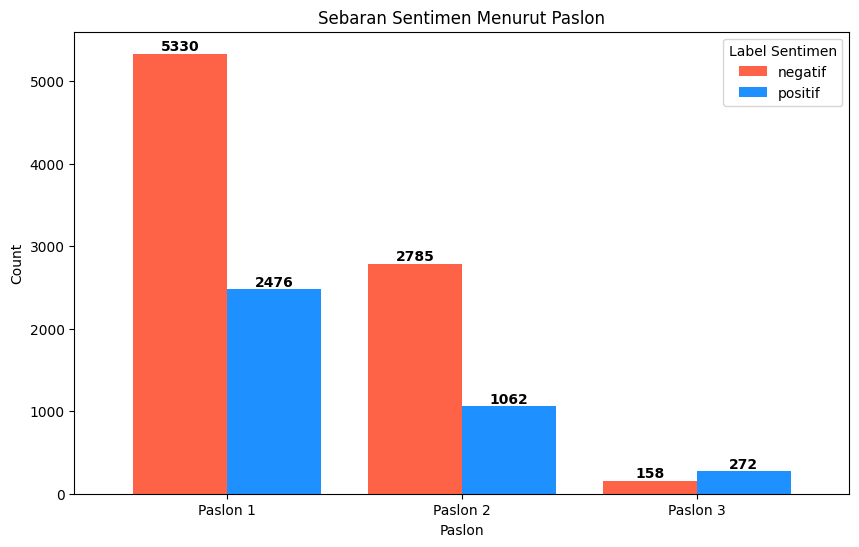

In [ ]:
# Data
data_plot2 = {
    'negatif': [5330, 2785, 158],
    'positif': [2476, 1062, 272]
}
sentiment_paslon = pd.DataFrame(data_plot2, index=['Paslon 1', 'Paslon 2', 'Paslon 3'])

# Colors for bars based on sentiment label
colors = ['#FF6347', '#1E90FF']

# Plotting the bar chart
ax = sentiment_paslon.plot(kind='bar', figsize=(10, 6), width=0.8, color=colors)
ax.set_title('Sebaran Sentimen Menurut Paslon')
ax.set_xlabel('Paslon')
ax.set_ylabel('Count')
ax.legend(title='Label Sentimen')

# Adding labels on top of the bars
for container in ax.containers:
    ax.bar_label(container, label_type='edge', color='black', fontsize=10, fontweight='bold')

# Display the plot
plt.xticks(rotation=0)
plt.show()

In [ ]:
bot_paslon = data.groupby(['paslon', 'is_bot', 'sentiment_label']).size().unstack(fill_value=0)
bot_paslon

sentiment_label  negative  positive
paslon   is_bot                    
Paslon 1 0           2457      1204
         1           2873      1272
Paslon 2 0           1224       525
         1           1561       537
Paslon 3 0             87       127
         1             71       145

In [ ]:
# jumlah sentimen untuk setiap kombinasi komunitas dan paslon
sentiment_count = data.groupby(['community', 'paslon', 'sentiment_label']).size().unstack(fill_value=0)
sentiment_count

sentiment_label     negative  positive
community paslon                      
1         Paslon 1      2252      1706
2         Paslon 1      1196       568
          Paslon 2      1286       250
          Paslon 3        70       193
3         Paslon 1       203       178
          Paslon 2       686       519
4         Paslon 1       123        24
          Paslon 2       809       293
          Paslon 3        88        79
5         Paslon 1      1090         0
          Paslon 2         1         0
6         Paslon 1       466         0
          Paslon 2         3         0